# Notebook 3 — Modelisation et Evaluation des Modeles

**Modeles utilises :**
1. Foret Aleatoire (Random Forest)
2. Gradient Boosting (XGBoost)
3. Reseau de Neurones (MLP — Multi-Layer Perceptron)

**Strategie de validation :** Validation croisee stratifiee 5-fold + split train/test final (80/20)

---

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import seaborn as sns
from pathlib import Path
import json, joblib, time

ROOT = Path('..').resolve()
DATA_PROC = ROOT / 'data' / 'processed'

X = pd.read_parquet(DATA_PROC / 'X_preprocessed.parquet')
y_df = pd.read_parquet(DATA_PROC / 'y_preprocessed.parquet')
y = y_df['FLAG_RESILIATION'].astype(int)

selected_features = joblib.load(ROOT / 'models' / 'selected_features.pkl')
X_sel = X[selected_features]

print(f"X_sel : {X_sel.shape},  y : {y.shape}")
print(f"Distribution : {y.value_counts().to_dict()}")

X_sel : (46842, 35),  y : (46842,)
Distribution : {0: 38438, 1: 8404}


## 3.1 Preparation — Split train/test + SMOTE

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from imblearn.over_sampling import SMOTE

X_train, X_test, y_train, y_test = train_test_split(
    X_sel, y, test_size=0.2, random_state=42, stratify=y
)

# SMOTE uniquement sur le train
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Train avant SMOTE  : {X_train.shape[0]:,} lignes | {y_train.value_counts().to_dict()}")
print(f"Train apres SMOTE  : {X_train_sm.shape[0]:,} lignes | {pd.Series(y_train_sm).value_counts().to_dict()}")
print(f"Test               : {X_test.shape[0]:,} lignes  | {y_test.value_counts().to_dict()}")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

Train avant SMOTE  : 37,473 lignes | {0: 30750, 1: 6723}
Train apres SMOTE  : 61,500 lignes | {0: 30750, 1: 30750}
Test               : 9,369 lignes  | {0: 7688, 1: 1681}


## 3.2 Modele 1 — Random Forest

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate

print("Entrainement Random Forest...")
t0 = time.time()

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Validation croisee 5-fold
cv_rf = cross_validate(
    rf, X_train_sm, y_train_sm, cv=cv,
    scoring=['accuracy','f1','roc_auc','precision','recall'],
    return_train_score=True, n_jobs=-1
)

print(f"Duree CV : {time.time()-t0:.1f}s")
print("\n--- Cross-validation (5-fold) ---")
for metric in ['test_accuracy','test_f1','test_roc_auc','test_precision','test_recall']:
    vals = cv_rf[metric]
    print(f"  {metric[5:]:12s} : {vals.mean():.4f} (+/- {vals.std():.4f})")

# Entrainement final
rf.fit(X_train_sm, y_train_sm)
joblib.dump(rf, ROOT / 'models' / 'random_forest.pkl')
print("\nModele RF sauvegarde.")

Entrainement Random Forest...


Duree CV : 18.3s

--- Cross-validation (5-fold) ---
  accuracy     : 0.9173 (+/- 0.0012)
  f1           : 0.9186 (+/- 0.0013)
  roc_auc      : 0.9712 (+/- 0.0017)
  precision    : 0.9045 (+/- 0.0009)
  recall       : 0.9332 (+/- 0.0026)



Modele RF sauvegarde.


## 3.3 Modele 2 — XGBoost

In [4]:
import xgboost as xgb

print("Entrainement XGBoost...")
t0 = time.time()

ratio = (y_train_sm == 0).sum() / (y_train_sm == 1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

cv_xgb = cross_validate(
    xgb_model, X_train_sm, y_train_sm, cv=cv,
    scoring=['accuracy','f1','roc_auc','precision','recall'],
    return_train_score=True, n_jobs=-1
)

print(f"Duree CV : {time.time()-t0:.1f}s")
print("\n--- Cross-validation (5-fold) ---")
for metric in ['test_accuracy','test_f1','test_roc_auc','test_precision','test_recall']:
    vals = cv_xgb[metric]
    print(f"  {metric[5:]:12s} : {vals.mean():.4f} (+/- {vals.std():.4f})")

xgb_model.fit(X_train_sm, y_train_sm)
joblib.dump(xgb_model, ROOT / 'models' / 'xgboost.pkl')
print("\nModele XGBoost sauvegarde.")

Entrainement XGBoost...


Duree CV : 2.6s

--- Cross-validation (5-fold) ---
  accuracy     : 0.9238 (+/- 0.0016)
  f1           : 0.9235 (+/- 0.0016)
  roc_auc      : 0.9797 (+/- 0.0013)
  precision    : 0.9271 (+/- 0.0020)
  recall       : 0.9199 (+/- 0.0029)



Modele XGBoost sauvegarde.


## 3.4 Modele 3 — Reseau de Neurones (MLP)

In [5]:
from sklearn.neural_network import MLPClassifier

print("Entrainement MLP...")
t0 = time.time()

mlp = MLPClassifier(
    hidden_layer_sizes=(256, 128, 64),
    activation='relu',
    solver='adam',
    alpha=0.001,
    batch_size=512,
    learning_rate='adaptive',
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=42
)

cv_mlp = cross_validate(
    mlp, X_train_sm, y_train_sm, cv=cv,
    scoring=['accuracy','f1','roc_auc','precision','recall'],
    return_train_score=True, n_jobs=1
)

print(f"Duree CV : {time.time()-t0:.1f}s")
print("\n--- Cross-validation (5-fold) ---")
for metric in ['test_accuracy','test_f1','test_roc_auc','test_precision','test_recall']:
    vals = cv_mlp[metric]
    print(f"  {metric[5:]:12s} : {vals.mean():.4f} (+/- {vals.std():.4f})")

mlp.fit(X_train_sm, y_train_sm)
joblib.dump(mlp, ROOT / 'models' / 'mlp.pkl')
print("\nModele MLP sauvegarde.")

Entrainement MLP...


Duree CV : 134.3s

--- Cross-validation (5-fold) ---
  accuracy     : 0.9179 (+/- 0.0079)
  f1           : 0.9207 (+/- 0.0076)
  roc_auc      : 0.9606 (+/- 0.0028)
  precision    : 0.8897 (+/- 0.0074)
  recall       : 0.9539 (+/- 0.0081)



Modele MLP sauvegarde.


## 3.5 Evaluation finale sur le jeu de test

In [6]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)

models = {
    'Random Forest': rf,
    'XGBoost'      : xgb_model,
    'MLP'          : mlp,
}

results = {}
for name, model in models.items():
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results[name] = {
        'Accuracy'        : accuracy_score(y_test, y_pred),
        'Precision'       : precision_score(y_test, y_pred, zero_division=0),
        'Recall'          : recall_score(y_test, y_pred),
        'F1-Score'        : f1_score(y_test, y_pred),
        'ROC-AUC'         : roc_auc_score(y_test, y_proba),
        'AP (PR-AUC)'     : average_precision_score(y_test, y_proba),
        'y_pred'          : y_pred,
        'y_proba'         : y_proba,
    }

# Tableau des metriques
metrics_df = pd.DataFrame({
    name: {k: v for k, v in r.items() if isinstance(v, float)}
    for name, r in results.items()
}).T.round(4)

print("=== Metriques sur le jeu de TEST ===")
print(metrics_df.to_string())

# Sauvegarde JSON
metrics_export = metrics_df.to_dict()
with open(ROOT / 'models' / 'metrics.json', 'w') as f:
    json.dump(metrics_export, f, indent=2)
print("\nMetriques sauvegardees : models/metrics.json")

=== Metriques sur le jeu de TEST ===
               Accuracy  Precision  Recall  F1-Score  ROC-AUC  AP (PR-AUC)
Random Forest    0.8800     0.6420  0.7490    0.6914   0.9250       0.7281
XGBoost          0.8904     0.6949  0.6936    0.6943   0.9226       0.7365
MLP              0.8707     0.6155  0.7448    0.6740   0.9053       0.6633

Metriques sauvegardees : models/metrics.json


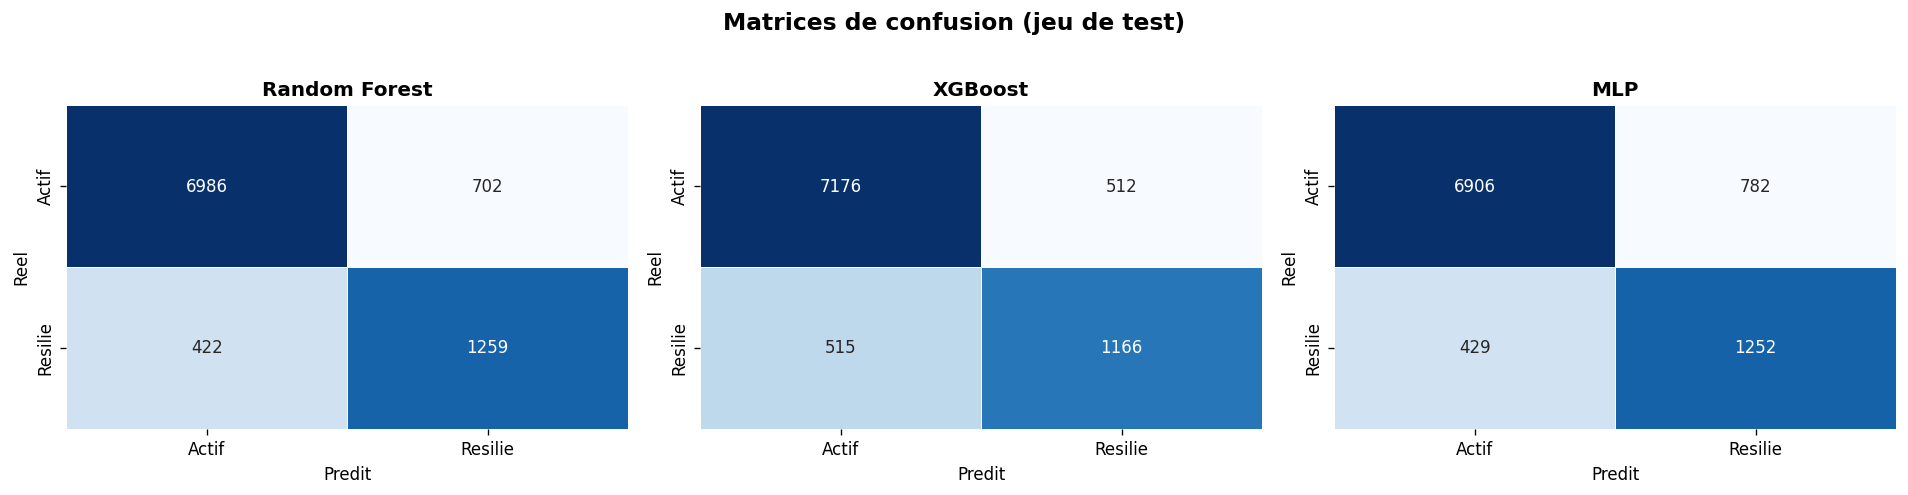

In [7]:
# Matrices de confusion
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Actif', 'Resilie'],
                yticklabels=['Actif', 'Resilie'],
                linewidths=0.5, cbar=False)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel('Predit')
    ax.set_ylabel('Reel')
plt.suptitle('Matrices de confusion (jeu de test)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'matrices_confusion.png', bbox_inches='tight')
plt.show()

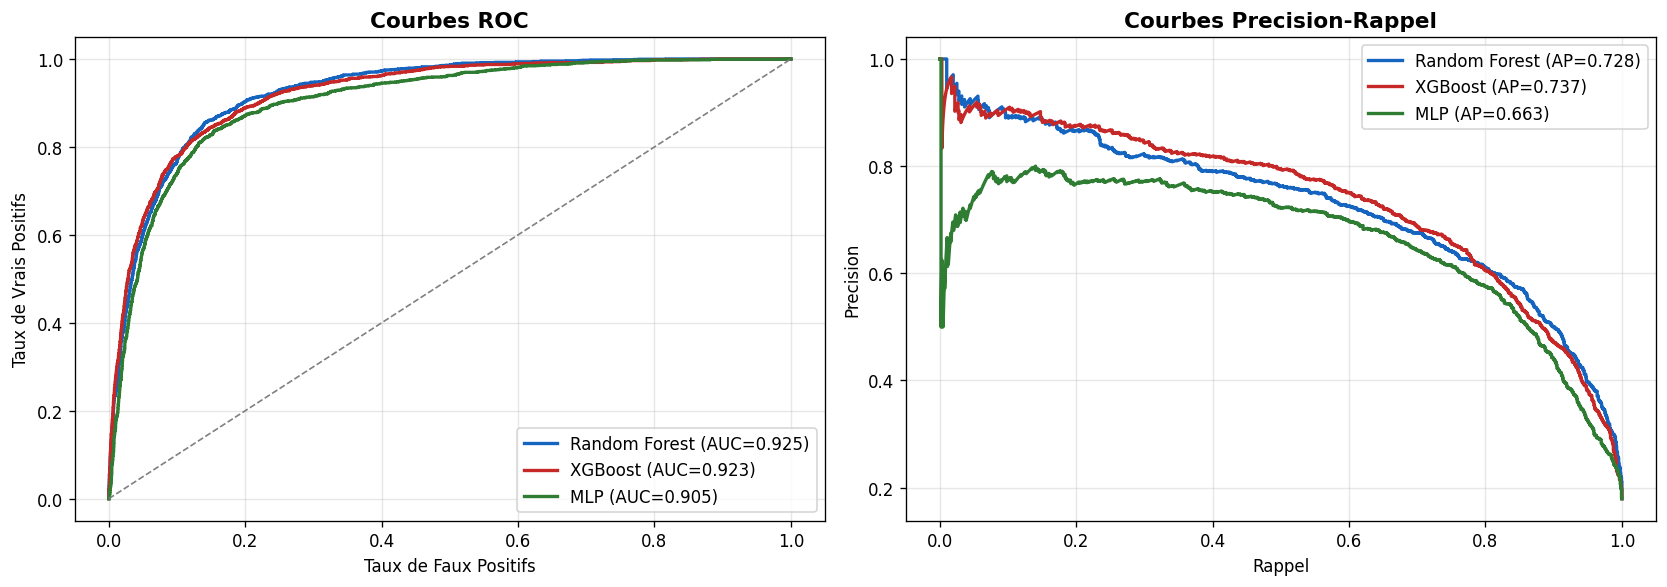

In [8]:
# Courbes ROC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#1565C0', '#C62828', '#2E7D32']
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc = res['ROC-AUC']
    axes[0].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})',
                 color=color, linewidth=2)

axes[0].plot([0,1],[0,1],'--', color='gray', linewidth=1)
axes[0].set_xlabel('Taux de Faux Positifs')
axes[0].set_ylabel('Taux de Vrais Positifs')
axes[0].set_title('Courbes ROC', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Courbes Precision-Recall
for (name, res), color in zip(results.items(), colors):
    prec, rec, _ = precision_recall_curve(y_test, res['y_proba'])
    ap = res['AP (PR-AUC)']
    axes[1].plot(rec, prec, label=f'{name} (AP={ap:.3f})',
                 color=color, linewidth=2)

axes[1].set_xlabel('Rappel')
axes[1].set_ylabel('Precision')
axes[1].set_title('Courbes Precision-Rappel', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'roc_pr_curves.png', bbox_inches='tight')
plt.show()

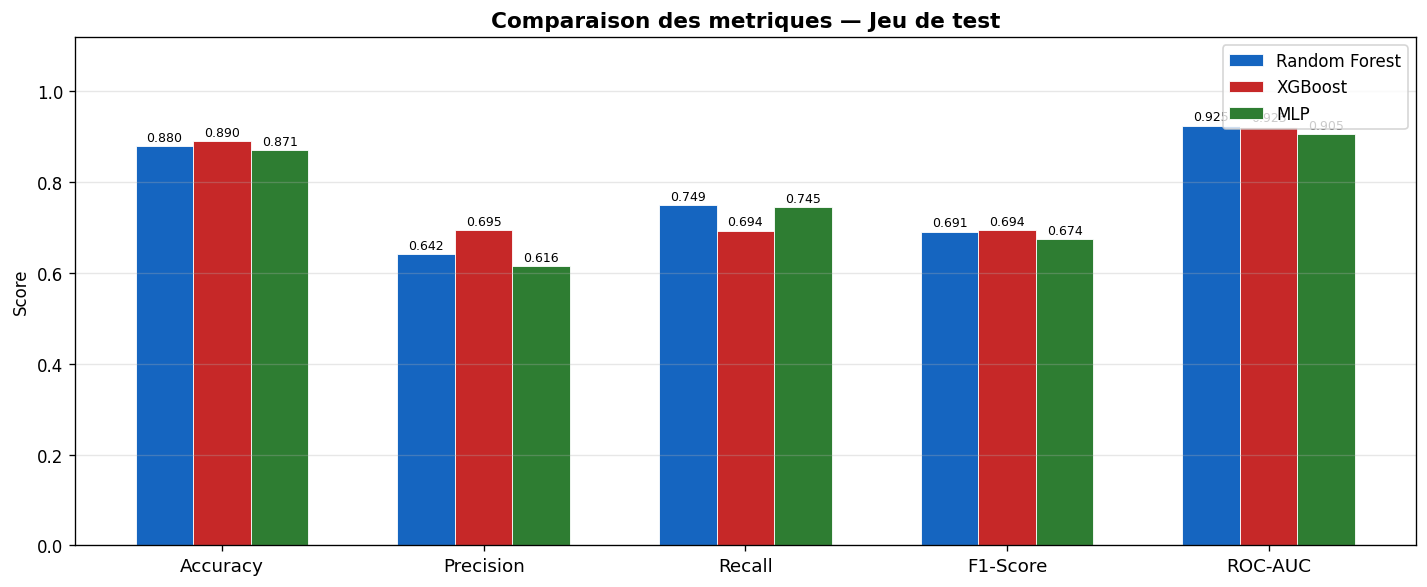

In [9]:
# Comparaison des metriques — graphique barres groupees
metrics_plot = metrics_df[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(metrics_plot.columns))
width = 0.22
colors_bar = ['#1565C0', '#C62828', '#2E7D32']
for i, (model_name, row) in enumerate(metrics_plot.iterrows()):
    bars = ax.bar(x + i*width, row.values, width, label=model_name,
                  color=colors_bar[i], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, row.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot.columns, fontsize=11)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.12)
ax.set_title('Comparaison des metriques — Jeu de test', fontsize=13, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'comparaison_modeles.png', bbox_inches='tight')
plt.show()

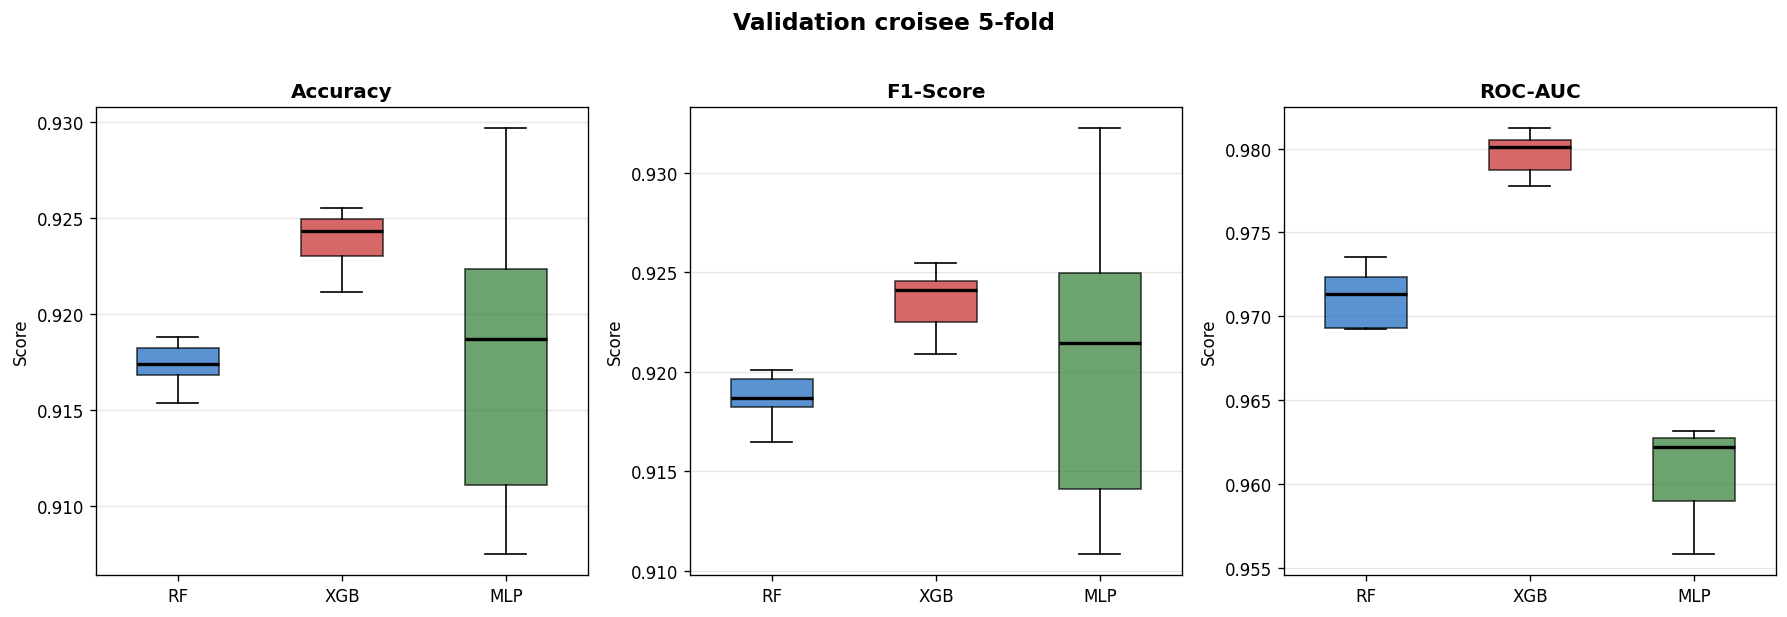

In [10]:
# Comparaison cross-validation
cv_results = {
    'Random Forest': cv_rf,
    'XGBoost'      : cv_xgb,
    'MLP'          : cv_mlp,
}
cv_metrics = ['test_accuracy','test_f1','test_roc_auc']
labels_cv  = ['Accuracy','F1-Score','ROC-AUC']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, metric, label in zip(axes, cv_metrics, labels_cv):
    data_box = [cv_results[m][metric] for m in ['Random Forest','XGBoost','MLP']]
    bp = ax.boxplot(data_box, patch_artist=True, widths=0.5,
                    medianprops={'color':'black','linewidth':2})
    for patch, color in zip(bp['boxes'], colors_bar):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_xticklabels(['RF','XGB','MLP'])
    ax.set_title(label, fontsize=12, fontweight='bold')
    ax.set_ylabel('Score')
    ax.grid(axis='y', alpha=0.3)

plt.suptitle('Validation croisee 5-fold', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(ROOT / 'rapport' / 'figures' / 'crossval_boxplot.png', bbox_inches='tight')
plt.show()

In [11]:
# Rapport de classification detaille
for name, res in results.items():
    print(f"\n{'='*55}")
    print(f"  {name}")
    print('='*55)
    print(classification_report(y_test, res['y_pred'],
                                 target_names=['Actif (0)','Resilie (1)']))

print("\nTous les modeles ont ete evalues et sauvegardes.")


  Random Forest
              precision    recall  f1-score   support

   Actif (0)       0.94      0.91      0.93      7688
 Resilie (1)       0.64      0.75      0.69      1681

    accuracy                           0.88      9369
   macro avg       0.79      0.83      0.81      9369
weighted avg       0.89      0.88      0.88      9369


  XGBoost
              precision    recall  f1-score   support

   Actif (0)       0.93      0.93      0.93      7688
 Resilie (1)       0.69      0.69      0.69      1681

    accuracy                           0.89      9369
   macro avg       0.81      0.81      0.81      9369
weighted avg       0.89      0.89      0.89      9369


  MLP
              precision    recall  f1-score   support

   Actif (0)       0.94      0.90      0.92      7688
 Resilie (1)       0.62      0.74      0.67      1681

    accuracy                           0.87      9369
   macro avg       0.78      0.82      0.80      9369
weighted avg       0.88      0.87      